In [4]:
import sounddevice as sd
from scipy.io import wavfile

fs = 16000
device = 14
seconds = 5

angles = ["045", "135", "225", "315"]

for angle in angles:
    print("Next: snap 3 times about 2 cm from the mic at", angle, "degrees")
    input("Press Enter to start recording...")
    data = sd.rec(int(seconds * fs), samplerate=fs, channels=6, device=device)
    sd.wait()
    wavfile.write("tap_" + angle + ".wav", fs, data)
    print("Saved tap_" + angle + ".wav")

print("Done, all four recorded")

Next: snap 3 times about 2 cm from the mic at 045 degrees
Saved tap_045.wav
Next: snap 3 times about 2 cm from the mic at 135 degrees
Saved tap_135.wav
Next: snap 3 times about 2 cm from the mic at 225 degrees
Saved tap_225.wav
Next: snap 3 times about 2 cm from the mic at 315 degrees
Saved tap_315.wav
Done, all four recorded


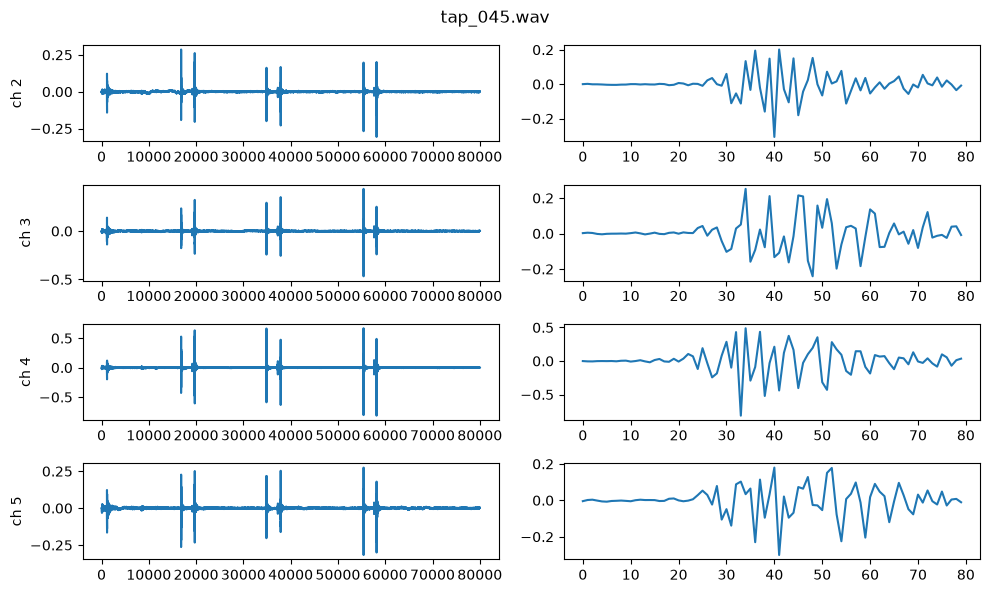

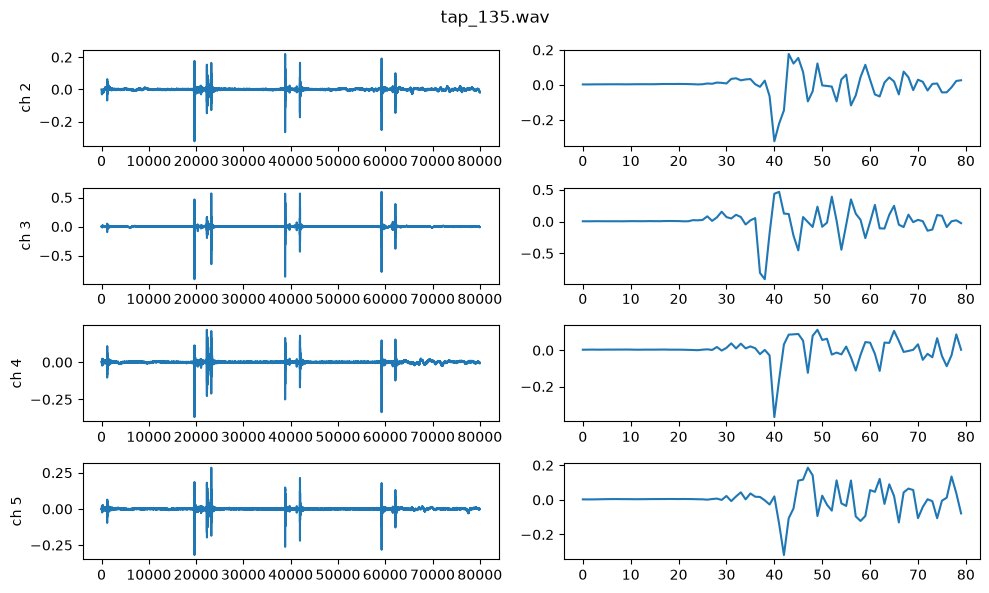

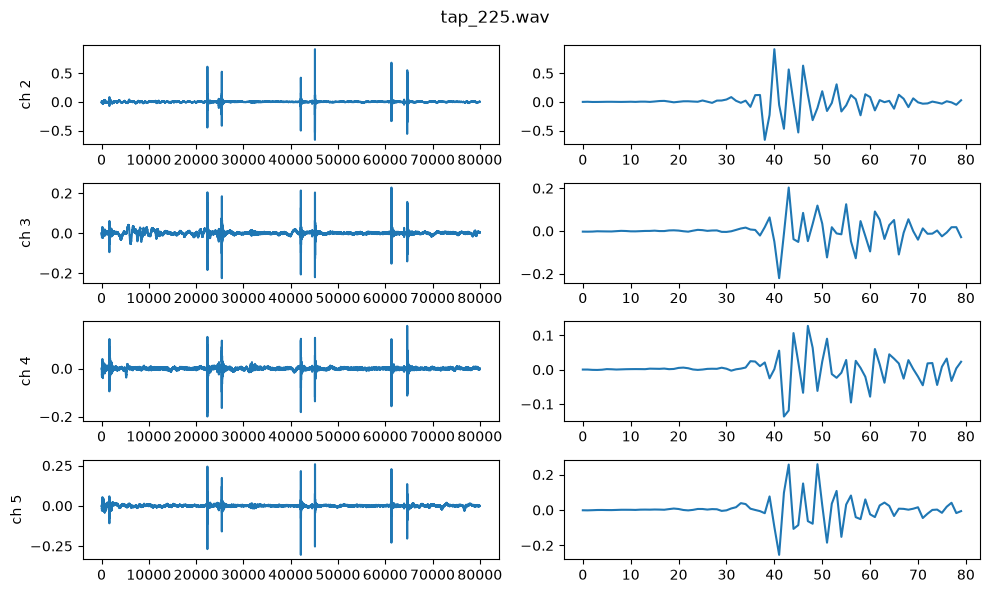

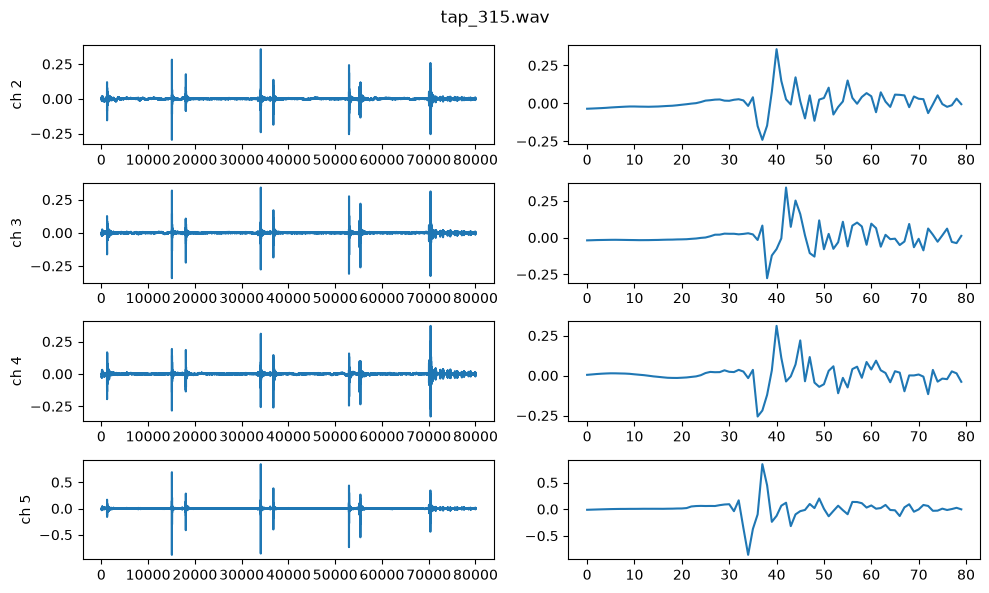

In [5]:
import numpy as np
import matplotlib.pyplot as plt

for angle in angles:
    rate, data = wavfile.read("tap_" + angle + ".wav")
    peak = np.argmax(np.abs(data[:, 2]))
    plt.figure(figsize=(10, 6))
    plt.suptitle("tap_" + angle + ".wav")
    for i in range(4):
        ch = i + 2
        plt.subplot(4, 2, 2 * i + 1)
        plt.plot(data[:, ch])
        plt.ylabel("ch " + str(ch))
        plt.subplot(4, 2, 2 * i + 2)
        plt.plot(data[peak - 40 : peak + 40, ch])
    plt.tight_layout()
    plt.show()